<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML321ENSkillsNetwork817-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Exploratory Data Analysis on Online Course Enrollment Data**


## Objectives


* Identify keywords in course titles using a WordCloud
* Calculate the summary statistics and visualizations of the online course content dataset
* Determine popular course genres
* Calculate the summary statistics and create visualizations of the online course enrollment dataset
* Identify courses with the greatest number of enrolled students


----


## Prepare and setup the lab environment


and import necessary class/methods in the packages


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

%matplotlib inline

In [3]:
# also set a random state
rs = 123

### Load and explore the dataset


First, let's load the datasets as `Pandas` dataframes and start some basic exploratory data analysis tasks on them.


In [4]:
# Point to the datasets stored on the cloud
course_genre_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/course_genre.csv"
ratings_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-ML0321EN-Coursera/labs/v2/module_3/ratings.csv"

In [5]:
course_df = pd.read_csv(course_genre_url)
ratings_df = pd.read_csv(ratings_url)

In [6]:
# Save datasets locally
course_df.to_csv("../data/raw/course_genre.csv", index=False)
ratings_df.to_csv("../data/raw/ratings.csv", index=False)

In [7]:
# Load datasets locally
course_df = pd.read_csv("../data/raw/course_genre.csv")
ratings_df = pd.read_csv("../data/raw/ratings.csv")

We will start by exploring the course genre dataset:


In [8]:
course_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   COURSE_ID        307 non-null    str  
 1   TITLE            307 non-null    str  
 2   Database         307 non-null    int64
 3   Python           307 non-null    int64
 4   CloudComputing   307 non-null    int64
 5   DataAnalysis     307 non-null    int64
 6   Containers       307 non-null    int64
 7   MachineLearning  307 non-null    int64
 8   ComputerVision   307 non-null    int64
 9   DataScience      307 non-null    int64
 10  BigData          307 non-null    int64
 11  Chatbot          307 non-null    int64
 12  R                307 non-null    int64
 13  BackendDev       307 non-null    int64
 14  FrontendDev      307 non-null    int64
 15  Blockchain       307 non-null    int64
dtypes: int64(14), str(2)
memory usage: 38.5 KB


### Dataset Structure and Initial Insights

The dataset contains information for **307 online courses** and **16 variables**, representing both course metadata and thematic categories associated with each course.

Several key observations can be made from the dataset structure:

* The dataset does not contain missing values, as all 307 records are complete across every column. This eliminates the need for imputation or missing-value treatment during preprocessing.

* Two columns (`COURSE_ID` and `TITLE`) contain textual metadata that uniquely identify each course. These variables provide descriptive information but cannot be directly used by most machine learning algorithms without further feature engineering.

* The remaining 14 columns represent course genres encoded as binary indicators (0 or 1). This structure corresponds to a **multi-label classification format**, where a single course can belong to multiple topics simultaneously.

* The genres cover a wide range of technology-related domains, including programming languages, data science, machine learning, cloud computing, databases, web development, big data, blockchain, and artificial intelligence applications. This diversity suggests that the recommendation system will need to capture relationships between multiple technical disciplines.

* Since genres are represented as binary features, they naturally form a **Bag-of-Words style representation** of course content. This makes the dataset particularly suitable for similarity-based recommendation techniques such as Cosine Similarity, Euclidean Distance, clustering algorithms, and dimensionality reduction methods.

* The absence of continuous numerical variables indicates that most of the information available for recommendation comes from categorical topic membership rather than quantitative course attributes.

* Because courses may share multiple genres, it is expected that some topics will exhibit strong overlap. Identifying these relationships can provide valuable insights into learning pathways and course similarity patterns.

* The relatively compact dataset size (307 courses) allows rapid experimentation with different recommendation algorithms while remaining representative of a real-world educational catalog.

Overall, the dataset provides a clean and well-structured foundation for developing content-based recommendation systems, where course similarities can be inferred from shared thematic characteristics.


Then we can take a quick look at its header rows


In [9]:
course_df.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


For example, the following course `accelerating deep learning with gpu` is associated with genres `Python`, `MachineLearning`, and `DataScience`


In [10]:
course_df.iloc[1, ]

COURSE_ID                                     ML0122EN
TITLE              accelerating deep learning with gpu
Database                                             0
Python                                               1
CloudComputing                                       0
DataAnalysis                                         0
Containers                                           0
MachineLearning                                      1
ComputerVision                                       0
DataScience                                          1
BigData                                              0
Chatbot                                              0
R                                                    0
BackendDev                                           0
FrontendDev                                          0
Blockchain                                           0
Name: 1, dtype: object

### Course Title Word Cloud

Course titles contain valuable information about the topics covered in the catalog. To obtain a high-level overview of the most common technologies and subject areas, a word cloud is generated using the terms appearing in course titles.


In [11]:
titles = " ".join(title for title in course_df['TITLE'].astype(str))

In [12]:
print(titles)

robots are coming  build iot apps with watson  swift  and node red accelerating deep learning with gpu consuming restful services using the reactive jax rs client analyzing big data in r using apache spark containerizing  packaging  and running a spring boot application cloud native security conference  data security data science bootcamp with r for university proffesors learn how to use docker containers for iterative development scorm test course create your first mongodb database testing microservices with the arquillian managed container cloud pak for integration essentials watson analytics for social media data science bootcamp with python for university professors  advance create a cryptocurrency trading algorithm in python data   ai essentials securing java microservices with eclipse microprofile json web token  microprofile jwt  enabling distributed tracing in microservices with zipkin sql access for hadoop ybrid cloud conference  ai pipelines lab dataops methodology data   ai 

We also want to filter common stop words and some less meaningful words:


In [13]:
# English Stopwords
stopwords = set(STOPWORDS)
stopwords.update(["getting started", "using", "enabling", "template", "university", "end", "introduction", "basic"])

Then, we create a ```WordCloud``` object and generate ```wordcloud``` from the titles.


In [14]:
wordcloud = WordCloud(stopwords=stopwords, background_color="white", width=800, height=400)

In [15]:
wordcloud.generate(titles)

We can use `plt.imshow()` method to visualize the generated wordcloud:


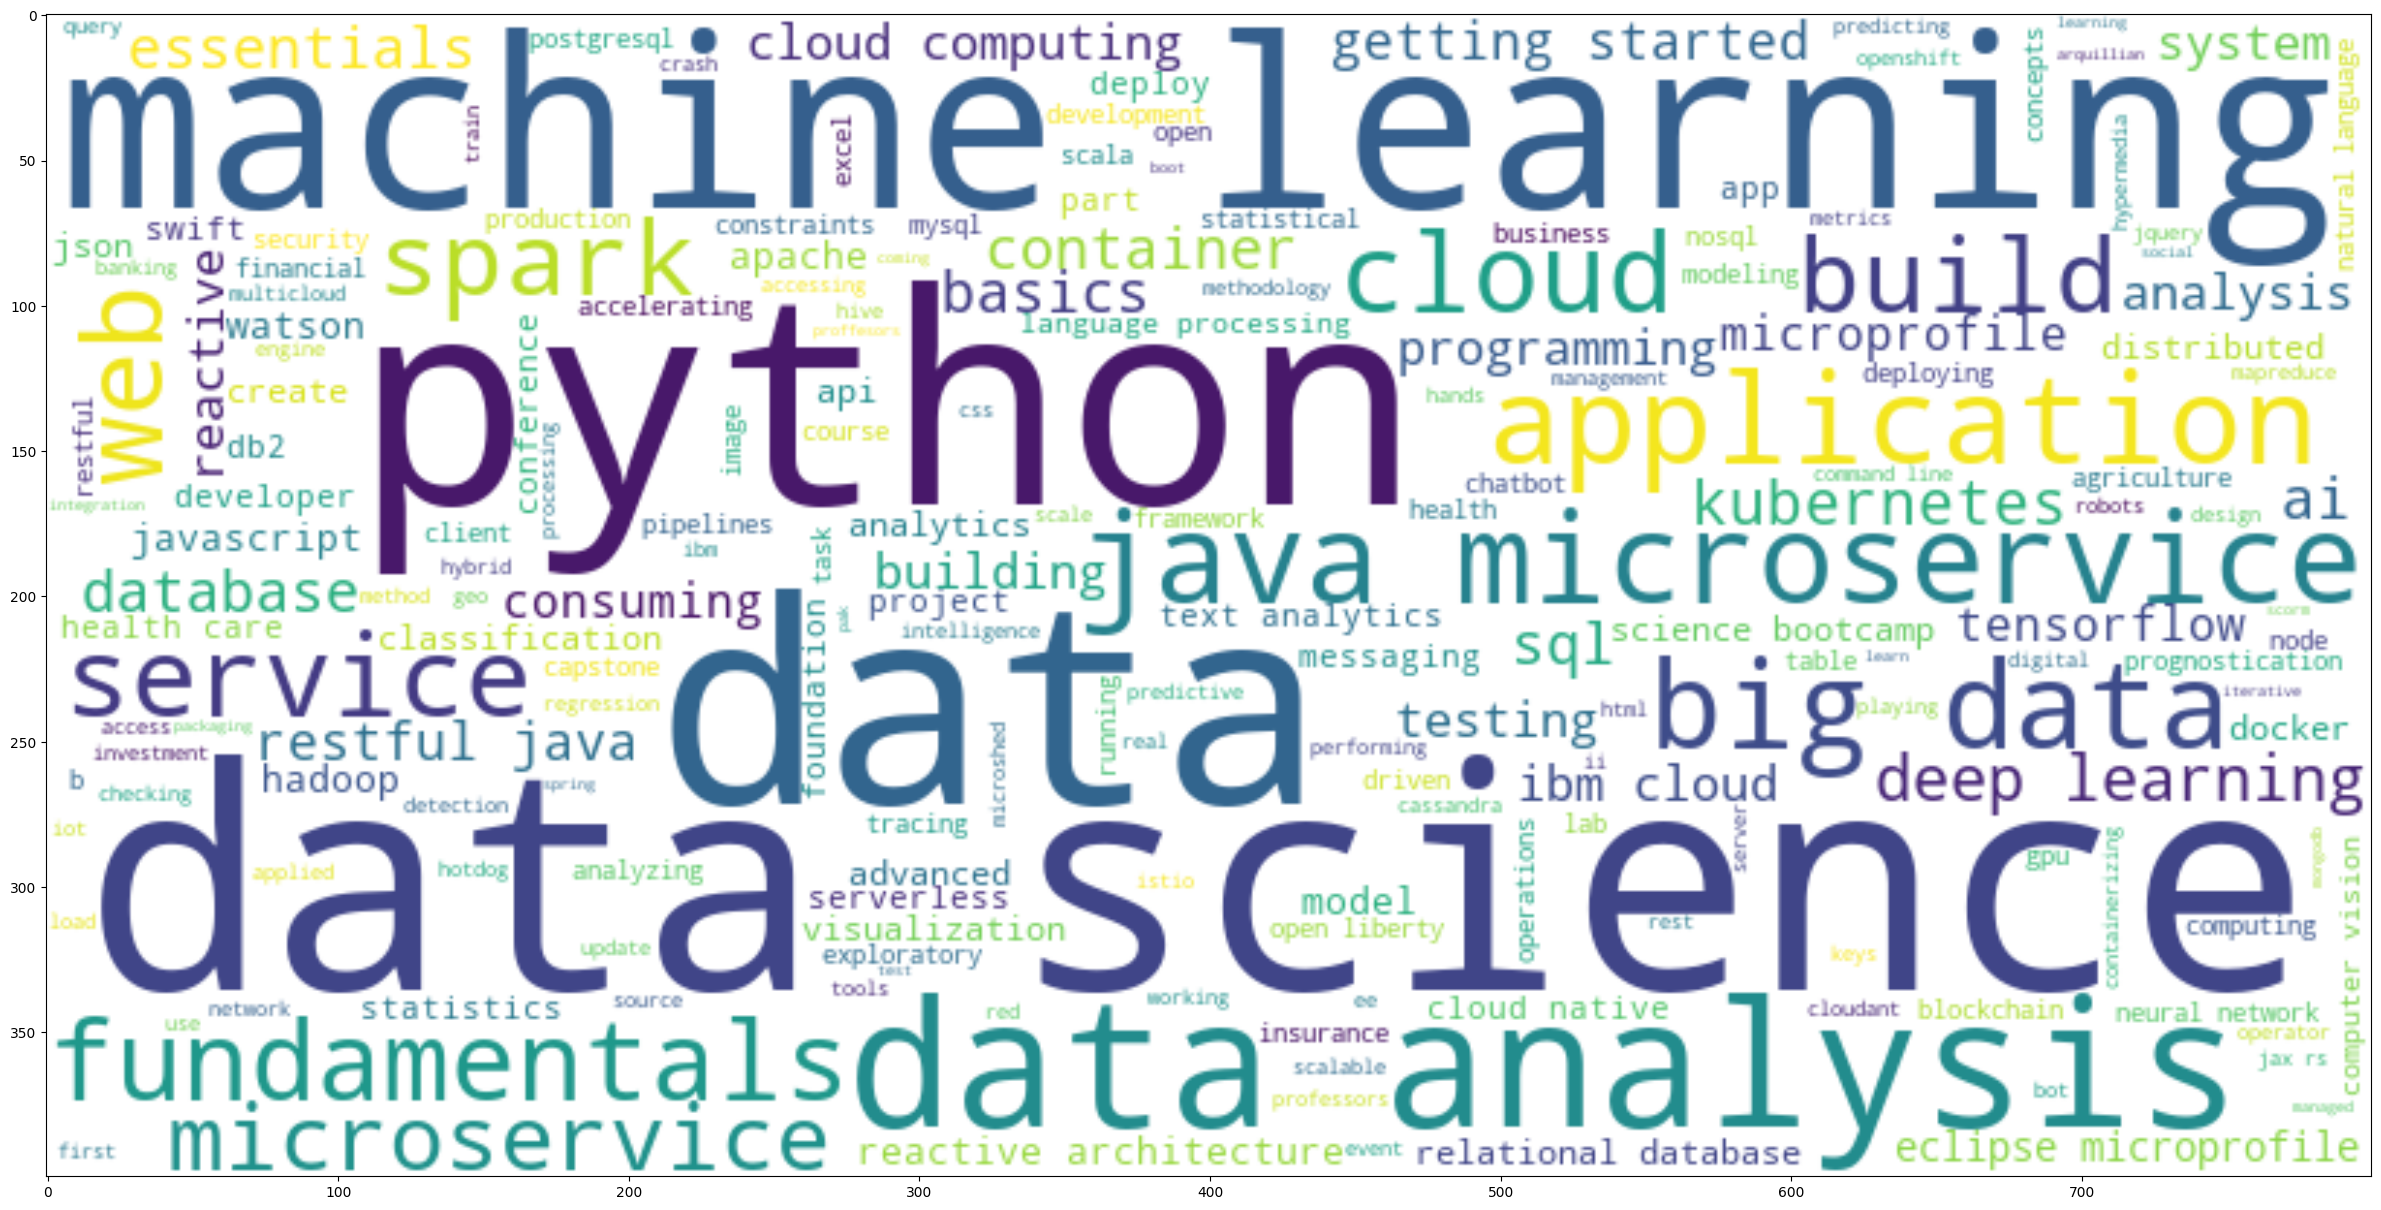

In [16]:
# Create a new figure with a specified size
plt.figure(figsize=(30,20))
# Adjust the layout to ensure tight spacing
plt.tight_layout(pad=0)
# Display the word cloud image with bilinear interpolation
plt.imshow(wordcloud, interpolation='bilinear')
# Show the plot
plt.show()

The word cloud highlights the most prominent topics represented in the course catalog, including Python, Data Science, Machine Learning, Artificial Intelligence, Big Data, Cloud Computing, and TensorFlow. The prevalence of these keywords indicates that the platform focuses on highly demanded technology skills and provides a diverse range of learning opportunities across software development, data science, AI, and cloud-related domains. This thematic information will be particularly valuable for building content-based recommendation models in later stages of the project.


### Machine Learning Course Analysis

To better understand the composition of the course catalog, we begin by identifying all courses associated with the Machine Learning genre. This analysis provides an overview of the available Machine Learning content and serves as a starting point for exploring course similarities and recommendation strategies.

In [17]:
# Filtrar cursos relacionados con Machine Learning
ml_courses = course_df[course_df["MachineLearning"] == 1]

# Mostrar los primeros resultados
ml_courses.head()

# Si quieres ver solo el título de los cursos:
ml_courses[["COURSE_ID", "TITLE"]]

,COURSE_ID,TITLE
1,ML0122EN,accelerating deep learning with gpu
15,DAI101EN,data ai essentials
19,HCC105EN,ybrid cloud conference ai pipelines lab
21,DS0132EN,data ai jumpstart your journey
24,BENTEST4,ai for everyone master the basics
...,...,...
274,excourse61,convolutional neural networks in tensorflow
282,excourse69,machine learning with big data
290,excourse77,natural language processing with attention models
291,excourse78,natural language processing with sequence models


### Scalable Machine Learning Courses

Courses that combine Machine Learning and Big Data concepts are particularly relevant for building scalable AI solutions. The following analysis identifies courses associated with both genres to explore this intersection within the catalog.

In [18]:
# Filtrar cursos que sean de Machine Learning y Big Data a la vez
scalable_ml_courses = course_df[(course_df["MachineLearning"] == 1) &
                                (course_df["BigData"] == 1)]

# Mostrar resultados
print(scalable_ml_courses[["COURSE_ID", "TITLE"]])

      COURSE_ID                                              TITLE
46   GPXX0BUBEN  insurance risk assessment with montecarlo meth...
59     TA0106EN                            text analytics at scale
184    BD0221EN                                        spark mllib
282  excourse69                     machine learning with big data


In [19]:
genres = course_df.columns[2:]
print(genres)

Index(['Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers',
       'MachineLearning', 'ComputerVision', 'DataScience', 'BigData',
       'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain'],
      dtype='str')


### Genre Distribution Analysis

To better understand the composition of the course catalog, we calculate the number of courses associated with each genre. Ranking genres by their frequency allows us to identify the most prevalent topics and provides a high-level overview of the platform's educational offerings.

In [20]:
genre_counts_df = (
    course_df[genres]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

genre_counts_df.columns = ["Genre", "Count"]

genre_counts_df.head()

,Genre,Count
0,BackendDev,78
1,MachineLearning,69
2,Database,60
3,DataAnalysis,56
4,DataScience,38


We can also visualize course genre counts using a bar chart:


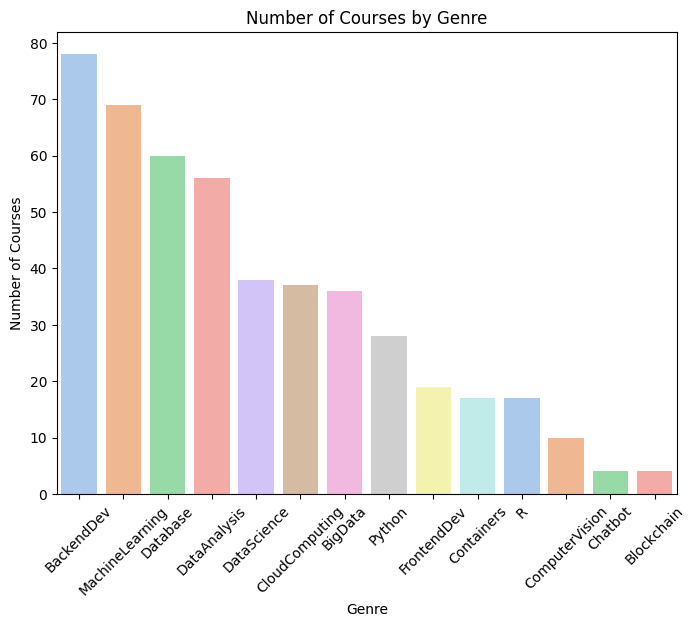

In [21]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=genre_counts_df,
    x="Genre",
    y="Count",
    hue="Genre",
    palette="pastel",
    dodge=False
)
plt.xticks(rotation=45)
plt.title("Number of Courses by Genre")
plt.ylabel("Number of Courses")
plt.xlabel("Genre")
plt.legend([],[], frameon=False)  # removes the legend
plt.show()

###  Course Enrollments


In [22]:
ratings_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


This dataset contains three colums, `user` representing a unique user id, `item` representing a course id, and `rating` representing the ratings given by the user.


In [23]:
ratings_df['rating'].unique()

array([5, 3, 4])

The **rating** column consists of three potential values:

- A rating of <code>5</code> signifies that users who have enrolled in the course find it excellent and have given it the highest rating, thus recommending it to other learners.

- A rating of <code>4</code>, indicates that the enrolled users perceive the course as good and will recommend to the other learners,but suggest minor improvements.

- A rating of <code>3</code>indicates that enrolled users find the course below expectations and need significant modifications.


Let's see how many ratings we have in the dataset:


In [24]:
ratings_df.shape[0]

233306

We have 233306 enrollments. In fact, each user is likely to interact with multiple items so let's find the rating counts for each user:


_TODO: Apply Pandas' groupby() and size() method on the user column to aggregate the rating count for each user, then report the total number of users after aggregation._


In [25]:
# Contar cuántos ratings tiene cada usuario
user_counts = ratings_df.groupby("user").size()

# Número total de usuarios únicos
total_users = user_counts.shape[0]
total_users

33901

Statistics summary of the user enrollments.


In [26]:
# Obtener estadísticas descriptivas de los conteos de ratings por usuario
user_counts.describe()



count    33901.000000
mean         6.881980
std          5.823548
min          1.000000
25%          2.000000
50%          6.000000
75%          9.000000
max         61.000000
dtype: float64

We can also get a histogram showing the enrollment distributions, e.g., how many users rated just 1 item or how many rated 10 items, etc.


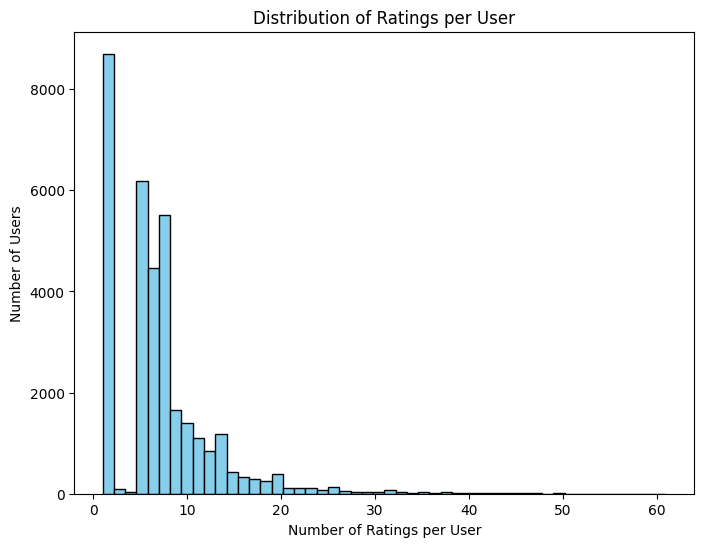

In [27]:
# Plot histogram of number of ratings per user
plt.figure(figsize=(8,6))
plt.hist(user_counts, bins=50, edgecolor="black", color="skyblue")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Ratings per User")
plt.show()


In [28]:
# Supongamos que 'user_counts' es una Serie con el número de ratings por usuario
# Creamos un DataFrame con la frecuencia de cada número de ratings
ratings_per_user_df = pd.DataFrame(user_counts.value_counts().sort_index())
ratings_per_user_df.columns = ['Number of Users']
ratings_per_user_df.index.name = 'Number of Ratings'
ratings_per_user_df.reset_index(inplace=True)

# Mostrar la tabla
ratings_per_user_df  # Muestra las primeras 10 filas como ejemplo


,Number of Ratings,Number of Users
0,1,8320
1,2,382
2,3,102
3,4,35
4,5,6179
5,6,4455
6,7,3168
7,8,2344
8,9,1665
9,10,1408


### Top-20 Most Popular Courses


In [29]:
import pandas as pd

# Contar cuántos ratings tiene cada curso
item_counts = ratings_df.groupby("item").size()

# Ordenar de mayor a menor
item_counts_sorted = item_counts.sort_values(ascending=False)

# Seleccionar el top 20
top20_courses = item_counts_sorted[:20]

# Crear DataFrame con las columnas requeridas
top20_table = pd.DataFrame({
    "Rank": range(1, 21),
    "Course Title": top20_courses.index,
    "Enrolls": top20_courses.values
})

# Mostrar la tabla
top20_table


,Rank,Course Title,Enrolls
0,1,PY0101EN,14936
1,2,DS0101EN,14477
2,3,BD0101EN,13291
3,4,BD0111EN,10599
4,5,DA0101EN,8303
5,6,DS0103EN,7719
6,7,ML0101ENv3,7644
7,8,BD0211EN,7551
8,9,DS0105EN,7199
9,10,BC0101EN,6719


In [30]:
ratings_df

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3
...,...,...,...
233301,1540125,DS0101EN,5
233302,1250651,PY0101EN,5
233303,1003832,CB0105ENv1,3
233304,922065,BD0141EN,4


To make it more clear, we need to join the course titles in the course metadata dataset (`course_df`) so that we can identify what the most popular courses are immediately:


In [31]:
# Convert top 20 series to DataFrame
top20_df = top20_courses.reset_index()
top20_df.columns = ["COURSE_ID", "Enrolls"]

# Merge with course_df to get course titles
top20_with_titles = pd.merge(top20_df, course_df[["COURSE_ID", "TITLE"]], on="COURSE_ID", how="left")

# Sort by Enrolls descending
top20_with_titles = top20_with_titles.sort_values(by="Enrolls", ascending=False)

# Add a numeric ranking column from 1 to 20
top20_with_titles.insert(0, "Rank", range(1, len(top20_with_titles) + 1))

# Keep only the columns Rank, TITLE, Enrolls
top20_final = top20_with_titles[["TITLE", "Enrolls"]]

# Display the final table
print(top20_final)


                                           TITLE  Enrolls
0                        python for data science    14936
1                   introduction to data science    14477
2                                   big data 101    13291
3                                     hadoop 101    10599
4                      data analysis with python     8303
5                       data science methodology     7719
6                   machine learning with python     7644
7                           spark fundamentals i     7551
8   data science hands on with open source tools     7199
9                          blockchain essentials     6719
10                data visualization with python     6709
11                             deep learning 101     6323
12                        build your own chatbot     5512
13                            r for data science     5237
14                                statistics 101     5015
15                         introduction to cloud     4983
16   docker es

It seems that those popular courses take a huge amount of total ratings. Let's find the exact percentage.


In [32]:
# Get the total course enrollments again
total = ratings_df.shape[0]
total

233306

In [33]:
# Sumar los ratings de los top 20 cursos
top20_total = top20_with_titles["Enrolls"].sum()

# Calcular el porcentaje sobre el total de enrollments
top20_percentage = (top20_total / total) * 100
print(f"Percentage: {top20_percentage:.2f}")

Percentage: 63.30
